SISTEMA DE ENTRENAMIENTO DE MODELO - RANDOM FOREST
Predicción de Planes Nutricionales para Pacientes con Diabetes

📁 Por favor, sube tu archivo CSV del dataset


Saving dataset_expandido_5500_registros.csv to dataset_expandido_5500_registros.csv

✓ Dataset cargado exitosamente con codificación utf-8
  Dimensiones: 5500 filas x 30 columnas

FASE 1: PREPROCESAMIENTO DE DATOS

📊 Información General del Dataset:
   • Total de registros: 5500
   • Total de variables: 30

🎯 Variable Objetivo: 'Tipo de plan nutricional recomendado'
🛠️  Variables (Features) Seleccionadas: 7 columnas

✓ Todas las columnas requeridas fueron encontradas.

⚙️ Limpiando y convirtiendo columnas numéricas...
   • Limpiando Peso actual (kg) (reemplazando ',' por '.')
   • Limpiando Talla (m) (reemplazando ',' por '.')
   • Limpiando IMC (Índice de Masa Corporal) (reemplazando ',' por '.')
   • Limpiando Circunferencia de cintura (cm) (reemplazando ',' por '.')
   ✓ Columnas numéricas limpias y sin nulos.

🔄 Codificando variables categóricas...
   ✓ Sexo: 2 categorías únicas
   ✓ Nivel de actividad física: 3 categorías únicas

   Tipos de planes nutricionales (Target):
   • Baj

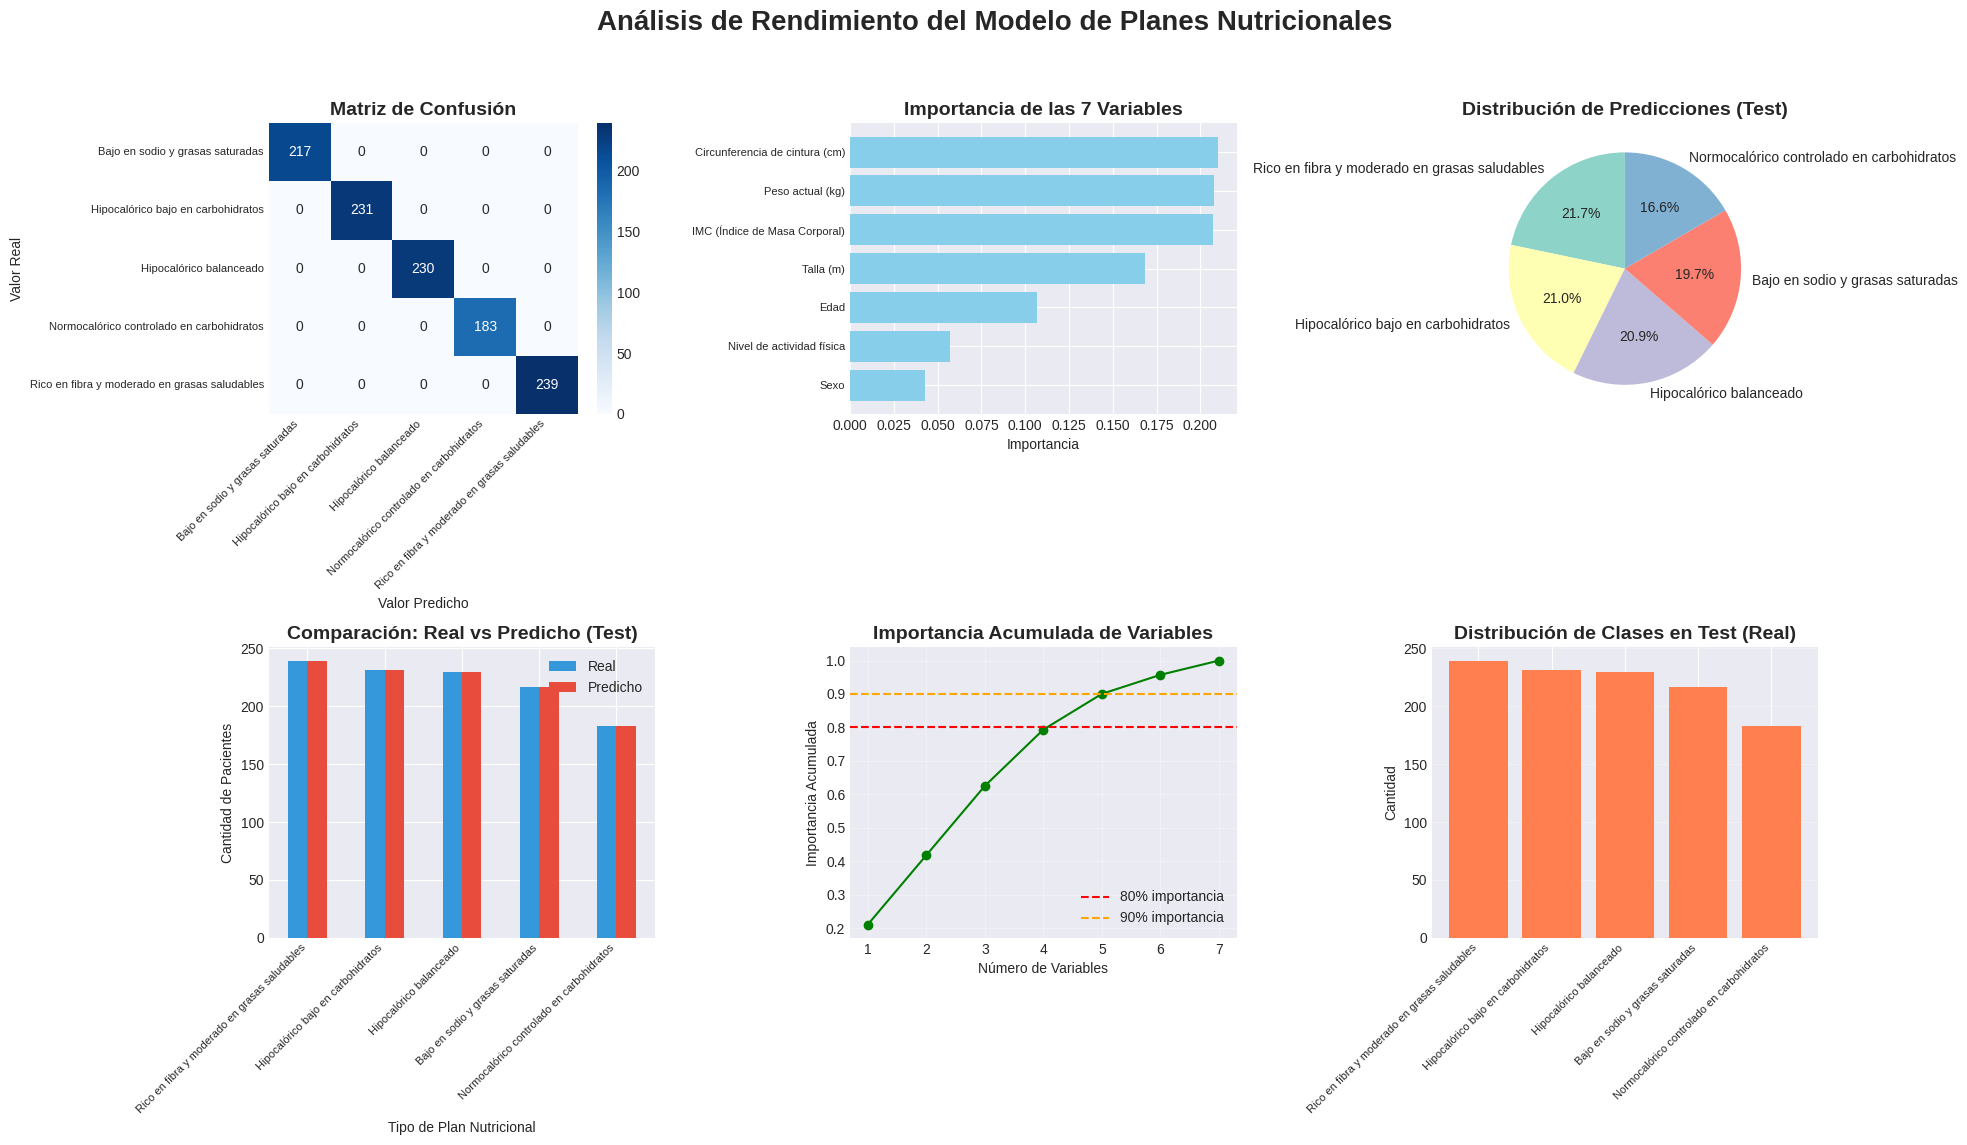


FASE 6: GUARDANDO MODELO

✅ Modelo guardado exitosamente como: 'modelo_random_forest_nutricion_7features.pkl'

📦 Contenido del archivo:
   • Modelo Random Forest entrenado
   • Codificadores de variables (3 encoders, incl. 'target')
   • Nombres de columnas (7 features)
   • Metadata del modelo (v1.1)

⬇️  Descargando modelo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DOCUMENTACIÓN COMPLETA DEL MODELO

╔══════════════════════════════════════════════════════════════════════════════╗
║                               RESUMEN EJECUTIVO DEL MODELO                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

📌 INFORMACIÓN GENERAL
--------------------------------------------------------------------------------
   Algoritmo: Random Forest Classifier
   Objetivo: Predecir el tipo de plan nutricional recomendado
   Número de árboles: 100
   Profundidad máxima: 20
   Total de características: 7 (Modelo enfocado)

🎯 RENDIMIENTO DEL MODELO
--------------------------------------------------------------------------------
   ✓ Precisión en Entrenamiento: 100.00%
   ✓ Precisión en Prueba: 100.00%
   Estado: ✅ Modelo bien balanceado (diferencia: 0.00%)

🔝 VARIABLES MÁS IMPORTANTES (de las 7 usadas)
--------------------------------------------------------------------------------
    1. Circunferencia de cintura (cm)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import pickle
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def cargar_dataset():
    """Carga el dataset desde un archivo CSV"""
    print("=" * 80)
    print("SISTEMA DE ENTRENAMIENTO DE MODELO - RANDOM FOREST")
    print("Predicción de Planes Nutricionales para Pacientes con Diabetes")
    print("=" * 80)
    print("\n📁 Por favor, sube tu archivo CSV del dataset")

    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # Intentar con diferentes codificaciones
    encodings = ['utf-8', 'utf-8-sig', 'latin-1', 'iso-8859-1', 'cp1252']
    df = None

    for encoding in encodings:
        try:
            # Se lee el CSV, la limpieza de decimales se hará manualmente
            df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';', encoding=encoding)
            print(f"\n✓ Dataset cargado exitosamente con codificación {encoding}")
            print(f"  Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
            break
        except Exception as e:
            print(f"Intento con {encoding} fallido: {e}")
            continue

    if df is None:
        raise Exception("❌ Error: No se pudo leer el archivo")

    return df

def preprocesar_datos(df):
    """Preprocesa el dataset para el entrenamiento"""
    print("\n" + "=" * 80)
    print("FASE 1: PREPROCESAMIENTO DE DATOS")
    print("=" * 80)

    # Información del dataset
    print("\n📊 Información General del Dataset:")
    print(f"   • Total de registros: {len(df)}")
    print(f"   • Total de variables: {len(df.columns)}")

    # --- INICIO BLOQUE DE MODIFICACIÓN ---

    # 1. Definir columnas explícitamente
    target_col = 'Tipo de plan nutricional recomendado'

    # Se ha quitado 'Porcentaje de grasa corporal (%)' de esta lista
    columnas_features_numericas = [
        'Edad',
        'Peso actual (kg)',
        'Talla (m)',
        'IMC (Índice de Masa Corporal)',
        'Circunferencia de cintura (cm)'
    ]
    columnas_features_categoricas = [
        'Sexo',
        'Nivel de actividad física'
    ]

    columnas_features = columnas_features_numericas + columnas_features_categoricas

    print(f"\n🎯 Variable Objetivo: '{target_col}'")
    print(f"🛠️  Variables (Features) Seleccionadas: {len(columnas_features)} columnas")

    # 2. Validar que todas las columnas necesarias existan
    columnas_requeridas = columnas_features + [target_col]
    columnas_faltantes = [col for col in columnas_requeridas if col not in df.columns]

    if len(columnas_faltantes) > 0:
        raise ValueError(f"❌ ERROR: Faltan las siguientes columnas en el CSV: {columnas_faltantes}")

    print("\n✓ Todas las columnas requeridas fueron encontradas.")

    # 3. Separar features y target
    X = df[columnas_features].copy()
    y = df[target_col]

    # 4. Limpiar y convertir columnas NUMÉRICAS
    print("\n⚙️ Limpiando y convirtiendo columnas numéricas...")
    for col in columnas_features_numericas:
        if X[col].dtype == 'object':
            print(f"   • Limpiando {col} (reemplazando ',' por '.')")
            # Convertir a string, reemplazar comas, luego convertir a numérico
            X[col] = X[col].astype(str).str.replace(',', '.', regex=False)

        # Convertir a numérico, forzando errores a NaN
        X[col] = pd.to_numeric(X[col], errors='coerce')

    # Manejar posibles NaNs creados por 'coerce'
    if X.isnull().sum().sum() > 0:
        print(f"   ⚠️  Se encontraron {X.isnull().sum().sum()} valores nulos. Rellenando con la mediana de cada columna.")
        for col in columnas_features_numericas:
            if X[col].isnull().any():
                median_val = X[col].median()
                X[col] = X[col].fillna(median_val)
    else:
        print("   ✓ Columnas numéricas limpias y sin nulos.")


    # 5. Codificar variables CATEGÓRICAS
    print("\n🔄 Codificando variables categóricas...")
    label_encoders = {}

    if len(columnas_features_categoricas) == 0:
        print("   • No se especificaron variables categóricas.")
    else:
        for col in columnas_features_categoricas:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
            print(f"   ✓ {col}: {len(le.classes_)} categorías únicas")

    # 6. Codificar target (Variable Objetivo)
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    label_encoders['target'] = le_target

    print(f"\n   Tipos de planes nutricionales (Target):")
    # Imprimir la distribución de la variable objetivo
    for i, plan in enumerate(le_target.classes_):
        count = (y_encoded == i).sum()
        porcentaje = (count / len(y_encoded)) * 100
        print(f"   • {plan}: {count} pacientes ({porcentaje:.1f}%)")

    # --- FIN BLOQUE DE MODIFICACIÓN ---

    # Guardar nombres de columnas originales
    nombres_columnas_originales = X.columns.tolist()

    print(f"\n✓ Preprocesamiento completado")
    print(f"   • Variables numéricas procesadas: {len(columnas_features_numericas)}")
    print(f"   • Variables categóricas codificadas: {len(columnas_features_categoricas)}")

    return X, y_encoded, label_encoders, nombres_columnas_originales

def dividir_datos(X, y):
    """Divide el dataset en entrenamiento y prueba"""
    print("\n" + "=" * 80)
    print("FASE 2: DIVISIÓN DE DATOS")
    print("=" * 80)

    # Dividir datos: 80% entrenamiento, 20% prueba
    # random_state=42 asegura resultados reproducibles
    # stratify=y asegura que la proporción de clases sea la misma en train y test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n📦 División de datos (80% entrenamiento / 20% prueba):")
    print(f"   • Conjunto de entrenamiento: {len(X_train)} registros")
    print(f"   • Conjunto de prueba: {len(X_test)} registros")

    return X_train, X_test, y_train, y_test

def entrenar_modelo(X_train, y_train):
    """Entrena el modelo Random Forest"""
    print("\n" + "=" * 80)
    print("FASE 3: ENTRENAMIENTO DEL MODELO")
    print("=" * 80)

    print("\n🌲 Configuración del Random Forest:")
    print("   • Número de árboles (n_estimators): 100")
    print("   • Profundidad máxima (max_depth): 20")
    print("   • Muestras mínimas para división (min_samples_split): 5")
    print("   • Muestras mínimas en hoja (min_samples_leaf): 2")
    print("   • Random state: 42 (para reproducibilidad)")

    print("\n⏳ Entrenando modelo... (esto puede tardar unos segundos)")

    # Inicializar el clasificador
    modelo = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1  # Usar todos los procesadores disponibles
    )

    # Entrenar el modelo
    modelo.fit(X_train, y_train)

    print("✓ Modelo entrenado exitosamente")

    return modelo

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, label_encoders):
    """Evalúa el rendimiento del modelo"""
    print("\n" + "=" * 80)
    print("FASE 4: EVALUACIÓN DEL MODELO")
    print("=" * 80)

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # Accuracy (Precisión)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\n📈 PRECISIÓN DEL MODELO:")
    print(f"   • Precisión en entrenamiento: {train_accuracy*100:.2f}%")
    print(f"   • Precisión en prueba: {test_accuracy*100:.2f}%")

    if test_accuracy >= 0.80:
        print(f"   ✅ ¡OBJETIVO CUMPLIDO! Precisión > 80%")
    else:
        print(f"   ⚠️  Precisión por debajo del objetivo de 80%")

    # Análisis de Overfitting (Sobreajuste)
    diferencia = abs(train_accuracy - test_accuracy) * 100
    if train_accuracy > test_accuracy and diferencia > 10:
         print(f"   ⚠️  ¡ALERTA DE OVERFITTING! Diferencia de {diferencia:.2f}% entre train y test.")
    elif train_accuracy > test_accuracy and diferencia > 5:
        print(f"   • Modelo con ligero overfitting (Diferencia: {diferencia:.2f}%)")
    else:
        print(f"   • Modelo bien generalizado (Diferencia: {diferencia:.2f}%)")


    # Validación cruzada (Cross-validation)
    print(f"\n🔄 Validación Cruzada (5-fold sobre datos de entrenamiento):")
    # Se usa X_train, y_train para la validación cruzada
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, n_jobs=-1)
    print(f"   • Precisión promedio: {cv_scores.mean()*100:.2f}%")
    print(f"   • Desviación estándar: ±{cv_scores.std()*100:.2f}%")
    print(f"   • Scores individuales: {[f'{s*100:.2f}%' for s in cv_scores]}")

    # Decodificar para reporte
    le_target = label_encoders['target']
    y_test_decoded = le_target.inverse_transform(y_test)
    y_test_pred_decoded = le_target.inverse_transform(y_test_pred)

    # Reporte de clasificación
    print(f"\n📋 REPORTE DETALLADO DE CLASIFICACIÓN (Conjunto de Prueba):")
    # Muestra precision, recall, f1-score por cada clase
    print("\n" + classification_report(y_test_decoded, y_test_pred_decoded, zero_division=0))

    return y_test_pred, train_accuracy, test_accuracy

def visualizar_resultados(modelo, X_train, y_test, y_test_pred, feature_names, label_encoders):
    """Genera visualizaciones del modelo"""
    print("\n" + "=" * 80)
    print("FASE 5: VISUALIZACIÓN DE RESULTADOS")
    print("=" * 80)

    # Decodificar etiquetas para los gráficos
    le_target = label_encoders['target']
    y_test_decoded = le_target.inverse_transform(y_test)
    y_test_pred_decoded = le_target.inverse_transform(y_test_pred)

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle("Análisis de Rendimiento del Modelo de Planes Nutricionales", fontsize=20, fontweight='bold')

    # 1. Matriz de Confusión
    plt.subplot(2, 3, 1)
    cm = confusion_matrix(y_test_decoded, y_test_pred_decoded, labels=le_target.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_)
    plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Valor Predicho')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    # 2. Importancia de Variables
    plt.subplot(2, 3, 2)
    importances = modelo.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Mostrar todas las variables (ahora son 7)
    top_n = len(feature_names)
    indices_top = indices[:top_n]

    plt.barh(range(top_n), importances[indices_top], color='skyblue')
    plt.yticks(range(top_n), [feature_names[i] for i in indices_top], fontsize=8)
    plt.xlabel('Importancia')
    plt.title(f'Importancia de las {top_n} Variables', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis() # La más importante arriba

    # 3. Distribución de Predicciones
    plt.subplot(2, 3, 3)
    pred_counts = pd.Series(y_test_pred_decoded).value_counts()
    colors = plt.cm.Set3(range(len(pred_counts)))
    plt.pie(pred_counts, labels=pred_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    plt.title('Distribución de Predicciones (Test)', fontsize=14, fontweight='bold')

    # 4. Comparación Real vs Predicho
    plt.subplot(2, 3, 4)
    comparison = pd.DataFrame({
        'Real': pd.Series(y_test_decoded).value_counts(),
        'Predicho': pd.Series(y_test_pred_decoded).value_counts()
    }).fillna(0) # Rellenar con 0 si una clase no fue predicha
    comparison.plot(kind='bar', ax=plt.gca(), color=['#3498db', '#e74c3c'])
    plt.title('Comparación: Real vs Predicho (Test)', fontsize=14, fontweight='bold')
    plt.xlabel('Tipo de Plan Nutricional')
    plt.ylabel('Cantidad de Pacientes')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.legend()

    # 5. Importancia Acumulada
    plt.subplot(2, 3, 5)
    cumsum = np.cumsum(sorted(importances, reverse=True))
    plt.plot(range(1, len(cumsum)+1), cumsum, marker='o', linestyle='-', color='green')
    plt.axhline(y=0.8, color='r', linestyle='--', label='80% importancia')
    plt.axhline(y=0.9, color='orange', linestyle='--', label='90% importancia')
    plt.xlabel('Número de Variables')
    plt.ylabel('Importancia Acumulada')
    plt.title('Importancia Acumulada de Variables', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 6. Distribución de Clases (Reales)
    plt.subplot(2, 3, 6)
    class_dist = pd.Series(y_test_decoded).value_counts()
    plt.bar(range(len(class_dist)), class_dist.values, color='coral')
    plt.xticks(range(len(class_dist)), class_dist.index, rotation=45, ha='right', fontsize=8)
    plt.ylabel('Cantidad')
    plt.title('Distribución de Clases en Test (Real)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el supertítulo
    plt.savefig('resultados_modelo.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualizaciones generadas y guardadas como 'resultados_modelo.png'")
    plt.show()

def guardar_modelo(modelo, label_encoders, nombres_columnas):
    """Guarda el modelo entrenado y sus componentes"""
    print("\n" + "=" * 80)
    print("FASE 6: GUARDANDO MODELO")
    print("=" * 80)

    # Crear diccionario con todos los componentes necesarios para la predicción
    modelo_completo = {
        'modelo': modelo,
        'label_encoders': label_encoders,
        'nombres_columnas': nombres_columnas, # Los 7 nombres de features
        'version': '1.1', # Versión actualizada
        'descripcion': 'Modelo Random Forest (7 features) para predicción de planes nutricionales'
    }

    # Guardar con pickle
    nombre_archivo = 'modelo_random_forest_nutricion_7features.pkl'
    with open(nombre_archivo, 'wb') as file:
        pickle.dump(modelo_completo, file)

    print(f"\n✅ Modelo guardado exitosamente como: '{nombre_archivo}'")
    print(f"\n📦 Contenido del archivo:")
    print(f"   • Modelo Random Forest entrenado")
    print(f"   • Codificadores de variables ({len(label_encoders)} encoders, incl. 'target')")
    print(f"   • Nombres de columnas ({len(nombres_columnas)} features)")
    print(f"   • Metadata del modelo (v1.1)")

    # Descargar el modelo
    print(f"\n⬇️  Descargando modelo...")
    files.download(nombre_archivo)

    return nombre_archivo

def generar_documentacion(modelo, X_train, train_accuracy, test_accuracy, feature_names):
    """Genera documentación completa del modelo"""
    print("\n" + "=" * 80)
    print("DOCUMENTACIÓN COMPLETA DEL MODELO")
    print("=" * 80)

    print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                               RESUMEN EJECUTIVO DEL MODELO                               ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

    print("📌 INFORMACIÓN GENERAL")
    print("-" * 80)
    print(f"   Algoritmo: Random Forest Classifier")
    print(f"   Objetivo: Predecir el tipo de plan nutricional recomendado")
    print(f"   Número de árboles: {modelo.n_estimators}")
    print(f"   Profundidad máxima: {modelo.max_depth}")
    print(f"   Total de características: {len(feature_names)} (Modelo enfocado)")

    print(f"\n🎯 RENDIMIENTO DEL MODELO")
    print("-" * 80)
    print(f"   ✓ Precisión en Entrenamiento: {train_accuracy*100:.2f}%")
    print(f"   ✓ Precisión en Prueba: {test_accuracy*100:.2f}%")

    diferencia = abs(train_accuracy - test_accuracy) * 100
    if train_accuracy > test_accuracy and diferencia > 10:
        estado = f"❌ Overfitting significativo (diferencia: {diferencia:.2f}%)"
    elif train_accuracy > test_accuracy and diferencia > 5:
        estado = f"⚠️  Ligero overfitting detectado (diferencia: {diferencia:.2f}%)"
    else:
        estado = f"✅ Modelo bien balanceado (diferencia: {diferencia:.2f}%)"

    print(f"   Estado: {estado}")

    print(f"\n🔝 VARIABLES MÁS IMPORTANTES (de las {len(feature_names)} usadas)")
    print("-" * 80)
    importances = modelo.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Mostrar todas las 7 variables, de la más a la menos importante
    for i, idx in enumerate(indices, 1):
        print(f"   {i:2d}. {feature_names[idx]:45s} - {importances[idx]*100:6.2f}%")

    print(f"\n📊 INTERPRETACIÓN DE RESULTADOS")
    print("-" * 80)
    print("""
    El modelo Random Forest ha sido entrenado exitosamente para predecir el tipo
    de plan nutricional más adecuado para pacientes con diabetes, utilizando un
    conjunto específico de 7 variables clave.

    ➤ FORTALEZAS DEL MODELO:
      • Capaz de modelar relaciones complejas entre variables numéricas y categóricas
      • Robusto ante valores atípicos (no requiere escalado de datos)
      • Proporciona importancia de características para interpretabilidad clínica

    ➤ VARIABLES CLAVE IDENTIFICADAS:
      El modelo ordena la importancia de las 7 variables proporcionadas.
      Esto permite entender qué factores (ej. IMC, Edad, Actividad Física)
      tienen más peso en la decisión del plan nutricional.


     """)

    print(f"\n💾 USO DEL MODELO GUARDADO")
    print("-" * 80)

    print(f"\n💾 ARCHIVOS GENERADOS")
    print("-" * 80)
    print("   • modelo_random_forest_nutricion_7features.pkl - Modelo entrenado completo")
    print("   • resultados_modelo.png - Visualizaciones del modelo")
    print("   • Esta documentación completa en consola")

    print("\n" + "=" * 80)
    print("FIN DE LA DOCUMENTACIÓN")
    print("=" * 80 + "\n")

def ejecutar_pipeline_completo():
    """Ejecuta todo el pipeline de entrenamiento y evaluación"""
    try:
        # 1. Cargar datos
        df = cargar_dataset()

        # 2. Preprocesar (Función modificada para usar solo 7 features)
        X, y, label_encoders, nombres_columnas = preprocesar_datos(df)

        # 3. Dividir datos
        X_train, X_test, y_train, y_test = dividir_datos(X, y)

        # 4. Entrenar
        modelo = entrenar_modelo(X_train, y_train)

        # 5. Evaluar
        y_test_pred, train_acc, test_acc = evaluar_modelo(
            modelo, X_train, X_test, y_train, y_test, label_encoders
        )

        # 6. Visualizar
        visualizar_resultados(modelo, X_train, y_test, y_test_pred,
                              X.columns.tolist(), label_encoders)

        # 7. Guardar modelo
        nombre_archivo_modelo = guardar_modelo(modelo, label_encoders, nombres_columnas)

        # 8. Documentar
        generar_documentacion(modelo, X_train, train_acc, test_acc, X.columns.tolist())

        print("\n" + "🎉" * 40)
        print("¡ENTRENAMIENTO COMPLETADO EXITOSAMENTE!")
        print("🎉" * 40 + "\n")

        print(f"✅ Modelo guardado y listo para usar con nuevos datos")
        print(f"✅ Descarga el archivo: {nombre_archivo_modelo}")

        return modelo, X, y, label_encoders

    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()

# EJECUTAR EL PIPELINE
if __name__ == "__main__":
    # En Google Colab, la celda se ejecuta, y esta llamada
    # iniciará todo el proceso.
    ejecutar_pipeline_completo()